In [1]:
import os
import sys
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

In [2]:
df = pd.read_csv('master_metadata.csv')
df.head()

,face_id,cea_grade,severity_label,erythema_type,erythema_pattern,clinical_analogue,ita,ita_band,fitzpatrick_est,melanin_vm,...,residual_amp,delta_a_star,contrast,hemo_after,mel_drift,out_drift,oxy_out_drift,eu_out_drift,mask_type,pipeline_version
0,9,0,none,vascular_erythema,butterfly,rosacea_inflammatory_flush,11.1368,tan,IV,0.3683,...,0.000000,0.0000,0.0000,0.4729,0.0000,0.0000,0.0000,0.0000,butterfly,v1.0
1,9,1,mild,vascular_erythema,butterfly,rosacea_inflammatory_flush,11.1368,tan,IV,0.3683,...,0.025313,0.5368,0.0338,0.4870,-0.0004,-0.0146,-0.0182,0.0070,butterfly,v1.0
2,9,2,moderate,vascular_erythema,butterfly,rosacea_inflammatory_flush,11.1368,tan,IV,0.3683,...,0.050625,0.9965,0.0162,0.5103,0.0016,-0.0143,-0.0182,0.0071,butterfly,v1.0
3,9,3,severe,vascular_erythema,butterfly,rosacea_inflammatory_flush,11.1368,tan,IV,0.3683,...,0.081563,1.4680,0.0256,0.5389,0.0042,-0.0140,-0.0181,0.0071,butterfly,v1.0
4,9,4,very_severe,vascular_erythema,butterfly,rosacea_inflammatory_flush,11.1368,tan,IV,0.3683,...,0.168750,2.1351,0.1007,0.6157,0.0116,-0.0130,-0.0180,0.0073,butterfly,v1.0


In [3]:
df.describe(include='all')


,face_id,cea_grade,severity_label,erythema_type,erythema_pattern,clinical_analogue,ita,ita_band,fitzpatrick_est,melanin_vm,...,residual_amp,delta_a_star,contrast,hemo_after,mel_drift,out_drift,oxy_out_drift,eu_out_drift,mask_type,pipeline_version
count,5000.000000,5000.000000,5000,5000,5000,5000,5000.000000,5000,5000,5000.000000,...,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000,5000
unique,NaN,NaN,5,1,1,1,NaN,6,6,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1
top,NaN,NaN,none,vascular_erythema,butterfly,rosacea_inflammatory_flush,NaN,very_light,I,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,butterfly,v1.0
freq,NaN,NaN,1000,5000,5000,5000,NaN,1120,1120,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5000,5000
mean,29826.641000,2.000000,NaN,NaN,NaN,NaN,23.844109,NaN,NaN,0.298492,...,0.040283,0.769444,0.029654,0.420346,0.001920,-0.002617,-0.014448,0.014399,NaN,NaN
std,17352.123582,1.414355,NaN,NaN,NaN,NaN,39.944148,NaN,NaN,0.159357,...,0.044871,0.825794,0.026984,0.105529,0.013617,0.012587,0.008859,0.017732,NaN,NaN
min,9.000000,0.000000,NaN,NaN,NaN,NaN,-81.084800,NaN,NaN,0.022000,...,0.000000,-0.348400,0.000000,0.000000,-0.101700,-0.056800,-0.031800,-0.040400,NaN,NaN
25%,15509.500000,1.000000,NaN,NaN,NaN,NaN,3.516925,NaN,NaN,0.183475,...,0.005000,0.000000,0.010000,0.337775,0.000000,-0.009200,-0.020500,0.000000,NaN,NaN
50%,29539.500000,2.000000,NaN,NaN,NaN,NaN,34.297650,NaN,NaN,0.271600,...,0.027344,0.505800,0.025200,0.416850,0.003200,-0.005100,-0.019400,0.014700,NaN,NaN
75%,44750.000000,3.000000,NaN,NaN,NaN,NaN,52.949050,NaN,NaN,0.375350,...,0.060000,1.378400,0.042525,0.503125,0.007700,0.000000,-0.007400,0.022000,NaN,NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   face_id            5000 non-null   int64  
 1   cea_grade          5000 non-null   int64  
 2   severity_label     5000 non-null   object 
 3   erythema_type      5000 non-null   object 
 4   erythema_pattern   5000 non-null   object 
 5   clinical_analogue  5000 non-null   object 
 6   ita                5000 non-null   float64
 7   ita_band           5000 non-null   object 
 8   fitzpatrick_est    5000 non-null   object 
 9   melanin_vm         5000 non-null   float64
 10  hemoglobin_vb      5000 non-null   float64
 11  oxygenation        5000 non-null   float64
 12  eumelanin_ratio    5000 non-null   float64
 13  residual_amp       5000 non-null   float64
 14  delta_a_star       5000 non-null   float64
 15  contrast           5000 non-null   float64
 16  hemo_after         5000 

# Phase 1 - Dataset Statistics 

## 1A - Distribution Plots 

In [5]:
counts = df.groupby('fitzpatrick_est')['face_id'].nunique()
print(counts)


fitzpatrick_est
I      224
II     190
III    155
IV     144
V      145
VI     142
Name: face_id, dtype: int64


In [6]:
counts = df.groupby('cea_grade')['face_id'].nunique()
print(counts)

cea_grade
0    1000
1    1000
2    1000
3    1000
4    1000
Name: face_id, dtype: int64


In [7]:
counts_1 = df.groupby('cea_grade')['fitzpatrick_est'].nunique()
print(counts)

cea_grade
0    1000
1    1000
2    1000
3    1000
4    1000
Name: face_id, dtype: int64


In [38]:
ceiling_hits = df[(df.cea_grade==4) & (df.delta_a_star < 2.0)]
print(f"{len(ceiling_hits)} identities failed to reach grade 4 target")
print(ceiling_hits.groupby('fitzpatrick_est').size())

398 identities failed to reach grade 4 target
fitzpatrick_est
I       73
II      22
III     10
IV      34
V      117
VI     142
dtype: int64


In [44]:
table = df.groupby(['fitzpatrick_est','cea_grade'])['delta_a_star'].agg(['mean','std']).round(3)
print(table.unstack('cea_grade'))

                mean                              std                       \
cea_grade          0      1      2      3      4    0      1      2      3   
fitzpatrick_est                                                              
I                0.0  0.418  0.823  1.235  1.958  0.0  0.179  0.321  0.474   
II               0.0  0.473  0.948  1.428  2.339  0.0  0.136  0.194  0.272   
III              0.0  0.496  0.992  1.474  2.416  0.0  0.109  0.128  0.167   
IV               0.0  0.460  0.916  1.366  2.162  0.0  0.128  0.206  0.293   
V                0.0  0.215  0.446  0.672  0.970  0.0  0.194  0.377  0.568   
VI               0.0 -0.060 -0.017  0.017  0.024  0.0  0.088  0.057  0.041   

                        
cea_grade            4  
fitzpatrick_est         
I                0.820  
II               0.487  
III              0.312  
IV               0.565  
V                0.878  
VI               0.053  


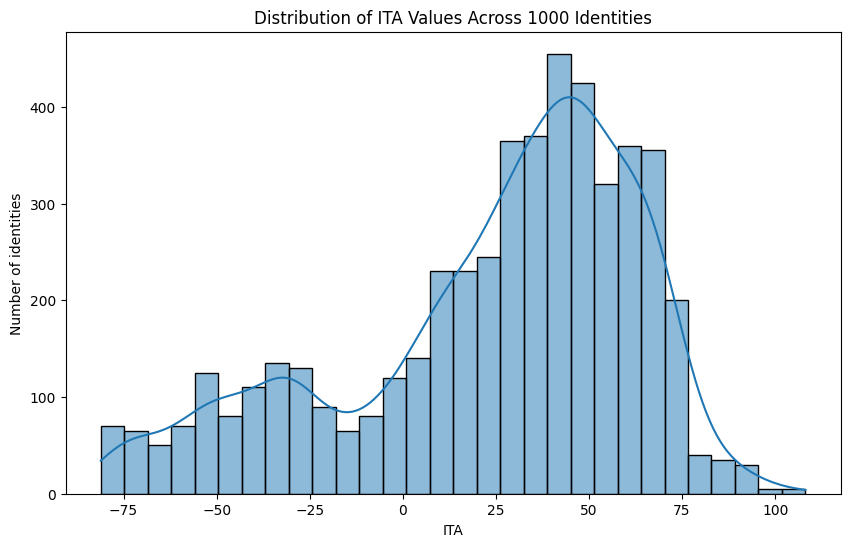

In [8]:
# ITA Histogram Plots across all 1000 identities

plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='ita', bins=30, kde=True)
plt.title('Distribution of ITA Values Across 1000 Identities')
plt.xlabel('ITA')
plt.ylabel('Number of identities')
plt.show()

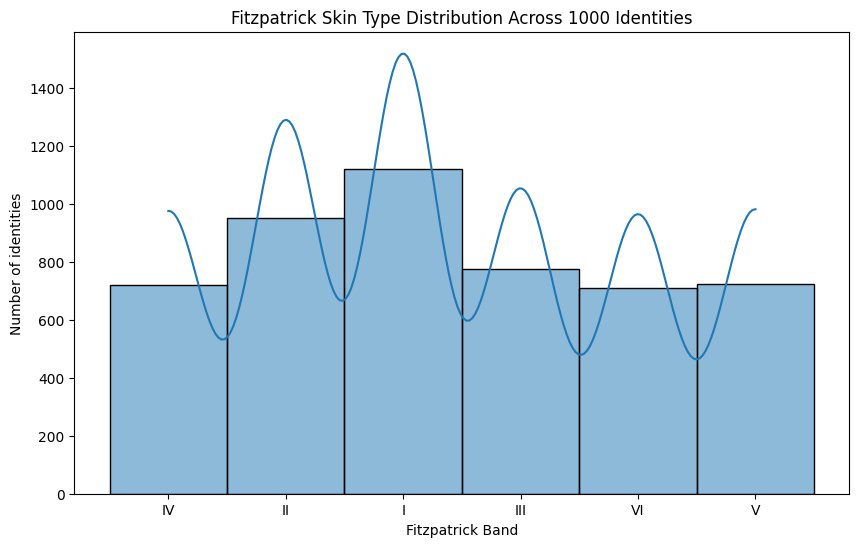

In [9]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='fitzpatrick_est', bins=30, kde=True)
plt.title('Fitzpatrick Skin Type Distribution Across 1000 Identities')    
plt.xlabel('Fitzpatrick Band')
plt.ylabel('Number of identities')
plt.show()

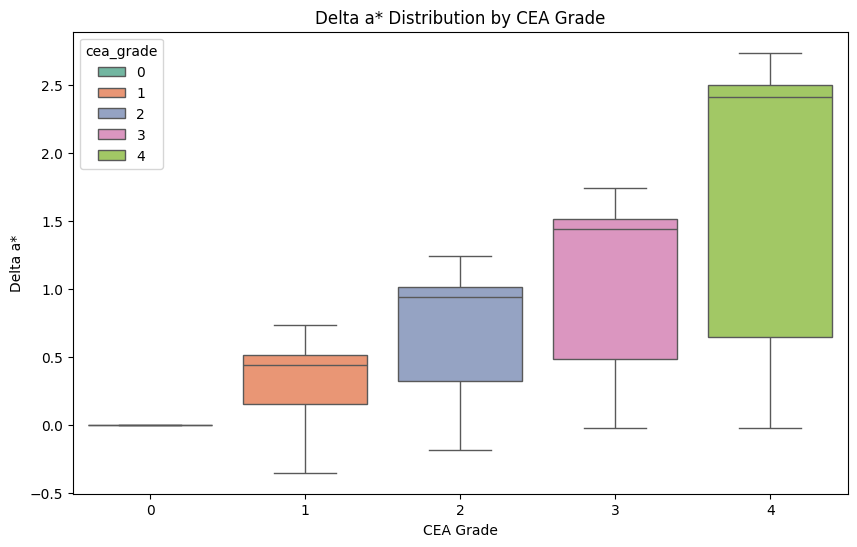

In [10]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='cea_grade', y='delta_a_star', hue='cea_grade', palette='Set2')
plt.title('Delta a* Distribution by CEA Grade')  
plt.xlabel('CEA Grade')
plt.ylabel('Delta a*')
plt.show()

## 1B · Vb Amplitude Vs Δa* Calibration Scatter

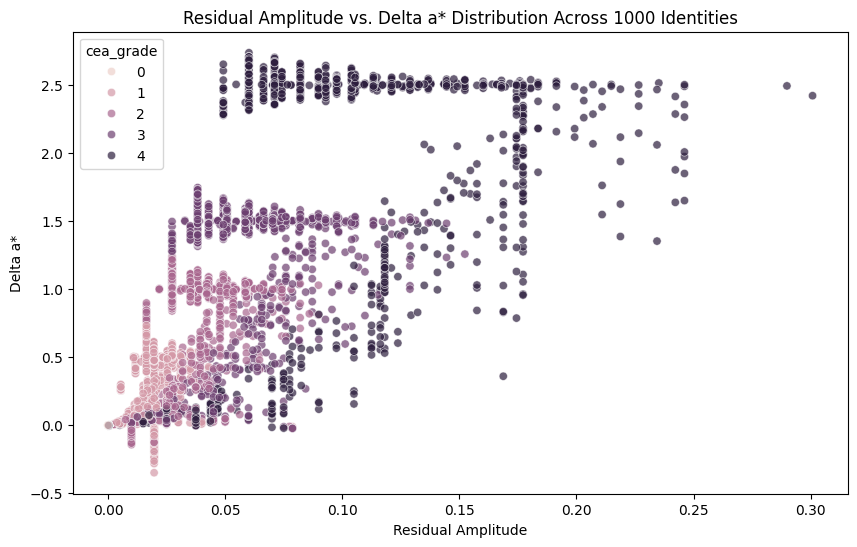

In [11]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='residual_amp', y='delta_a_star', hue='cea_grade',  alpha=0.7)
plt.title('Residual Amplitude vs. Delta a* Distribution Across 1000 Identities')
plt.xlabel('Residual Amplitude')
plt.ylabel('Delta a*')
plt.show()

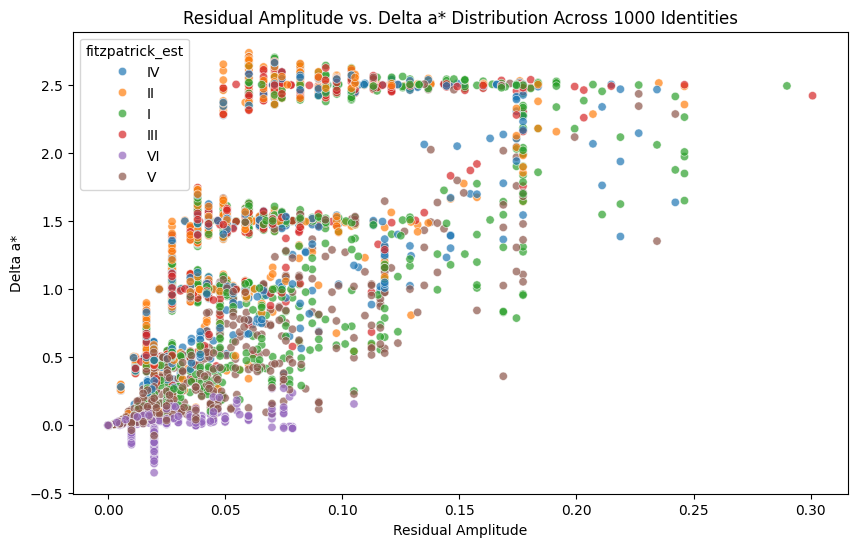

In [12]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='residual_amp', y='delta_a_star', hue='fitzpatrick_est',  alpha=0.7)
plt.title('Residual Amplitude vs. Delta a* Distribution Across 1000 Identities')
plt.xlabel('Residual Amplitude')
plt.ylabel('Delta a*')
plt.show()

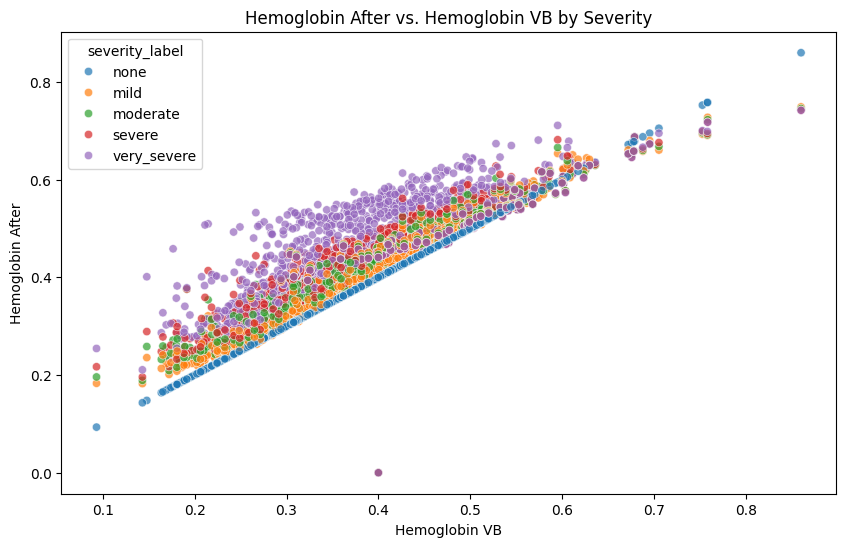

In [13]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x='hemoglobin_vb',
    y='hemo_after',
    hue='severity_label',
    alpha=0.7
)
plt.title('Hemoglobin After vs. Hemoglobin VB by Severity')
plt.xlabel('Hemoglobin VB')
plt.ylabel('Hemoglobin After')
plt.show()

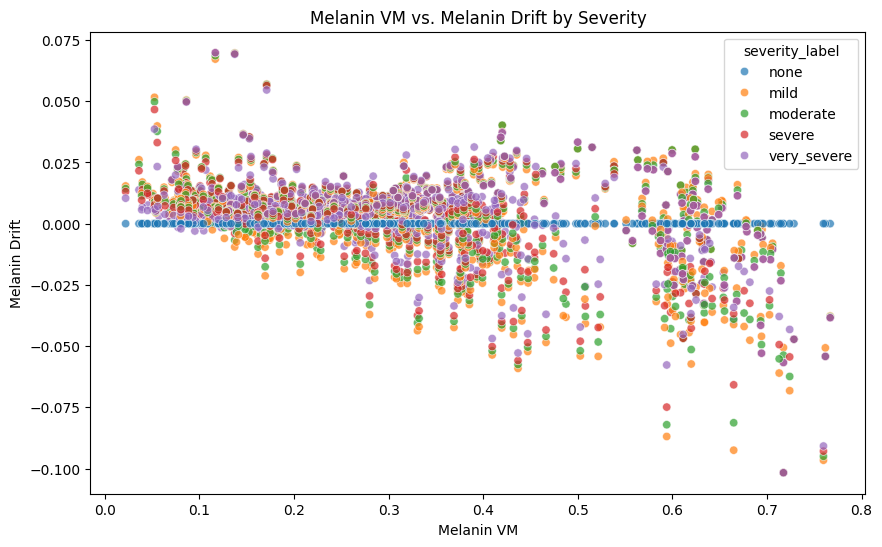

In [14]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x='melanin_vm',
    y='mel_drift',
    hue='severity_label',
    alpha=0.7
)
plt.title('Melanin VM vs. Melanin Drift by Severity')
plt.xlabel('Melanin VM')
plt.ylabel('Melanin Drift')
plt.show()

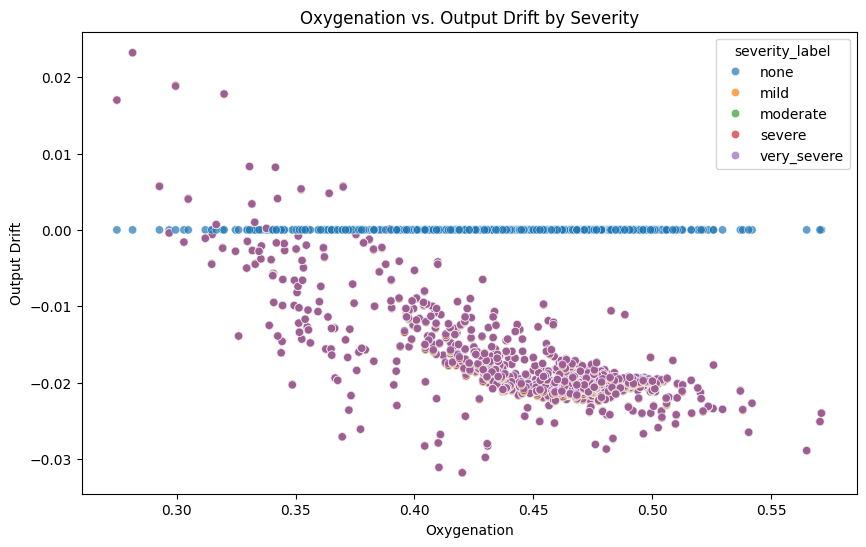

In [15]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x='oxygenation',
    y='oxy_out_drift',
    hue='severity_label',
    alpha=0.7
)
plt.title('Oxygenation vs. Output Drift by Severity')
plt.xlabel('Oxygenation')
plt.ylabel('Output Drift')
plt.show()

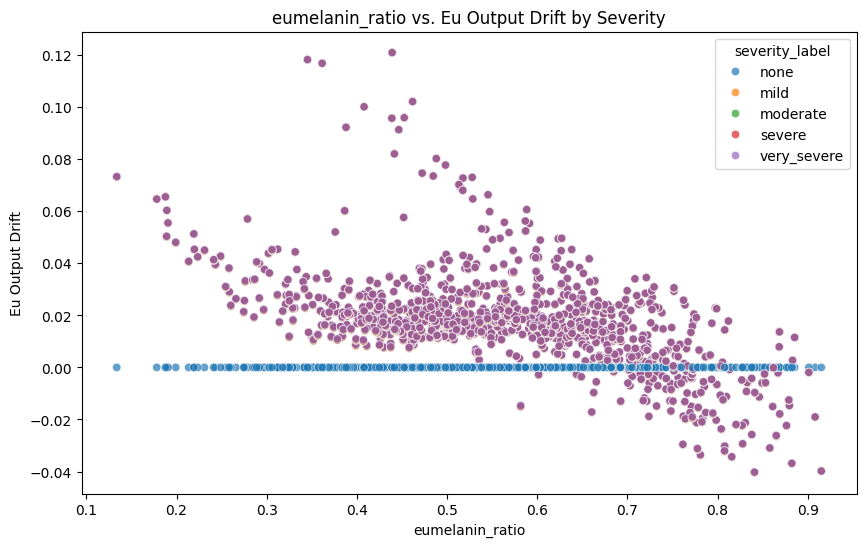

In [16]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x='eumelanin_ratio',
    y='eu_out_drift',
    hue='severity_label',
    alpha=0.7
)
plt.title('eumelanin_ratio vs. Eu Output Drift by Severity')
plt.xlabel('eumelanin_ratio')
plt.ylabel('Eu Output Drift')
plt.show()

## Phase 2 — Skin-Tone Fairness

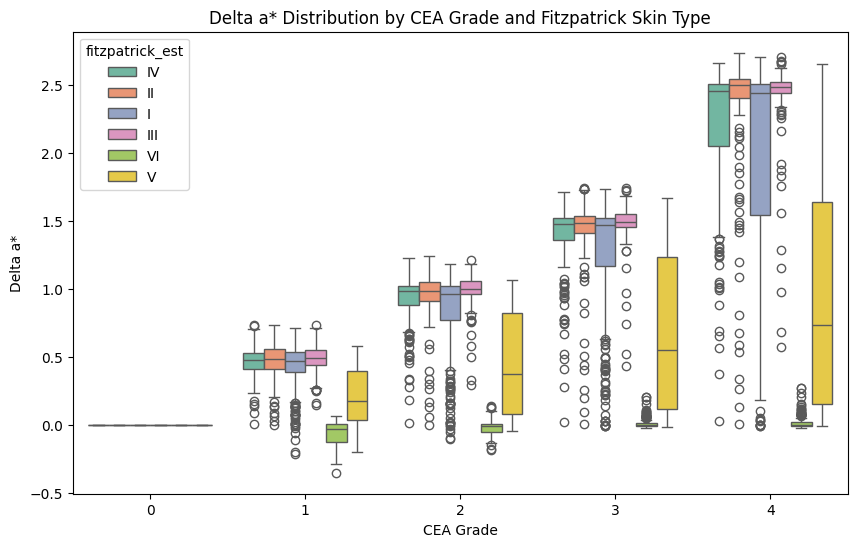

In [17]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='cea_grade', y='delta_a_star', hue='fitzpatrick_est', palette='Set2')
plt.title('Delta a* Distribution by CEA Grade and Fitzpatrick Skin Type')
plt.xlabel('CEA Grade')
plt.ylabel('Delta a*')
plt.show()

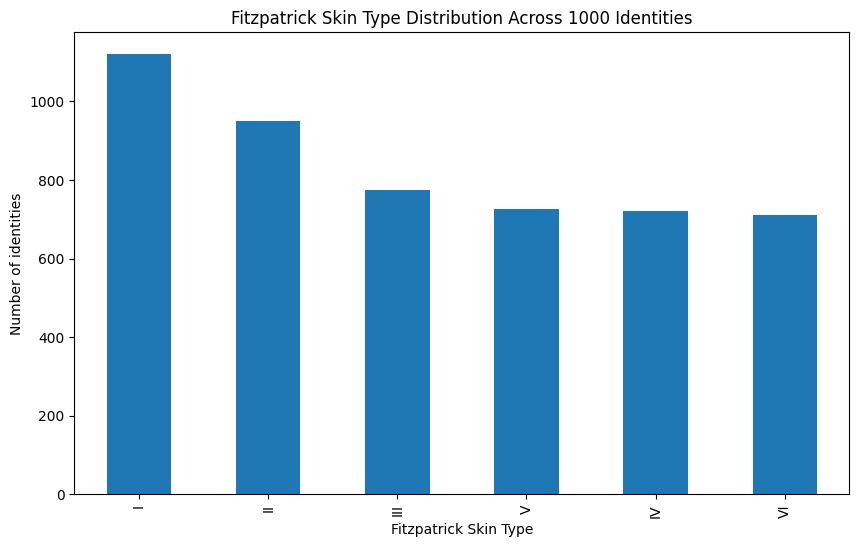

In [19]:
df['fitzpatrick_est'].value_counts().plot(kind='bar', figsize=(10, 6))
plt.title('Fitzpatrick Skin Type Distribution Across 1000 Identities')
plt.xlabel('Fitzpatrick Skin Type')
plt.ylabel('Number of identities')
plt.show()

In [23]:
unique = df['fitzpatrick_est'].nunique()
print(f"Number of unique Fitzpatrick skin types: {unique}")

Number of unique Fitzpatrick skin types: 6


In [24]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['fitzpatrick_encoded'] = le.fit_transform(df['fitzpatrick_est'])
print(df[['fitzpatrick_est', 'fitzpatrick_encoded']].head())

  fitzpatrick_est  fitzpatrick_encoded
0              IV                    3
1              IV                    3
2              IV                    3
3              IV                    3
4              IV                    3


In [37]:
for grade in [1,2,3,4]:
    groups = [group['delta_a_star'].values 
              for _, group in df[df.cea_grade==grade].groupby('fitzpatrick_est')]
    stat, p = stats.kruskal(*groups)
    print(f"Grade {grade}: H={stat:.3f}, p={p:.4f}")

Grade 1: H=470.319, p=0.0000
Grade 2: H=484.206, p=0.0000
Grade 3: H=472.524, p=0.0000
Grade 4: H=512.028, p=0.0000


In [43]:
from scikit_posthocs  import posthoc_dunn
for grade in [1,2,3,4]:
    subset = df[df.cea_grade==grade]
    result = posthoc_dunn(subset, val_col='delta_a_star', group_col='fitzpatrick_est')
    print(f"\nGrade {grade}:\n", result)


Grade 1:
                 I            II           III            IV             V  \
I    1.000000e+00  4.922968e-02  4.524761e-03  2.667031e-01  1.857330e-16   
II   4.922968e-02  1.000000e+00  3.428746e-01  4.953877e-01  2.604360e-22   
III  4.524761e-03  3.428746e-01  1.000000e+00  1.240963e-01  2.962187e-24   
IV   2.667031e-01  4.953877e-01  1.240963e-01  1.000000e+00  2.550294e-17   
V    1.857330e-16  2.604360e-22  2.962187e-24  2.550294e-17  1.000000e+00   
VI   3.328621e-56  5.554188e-65  7.495698e-66  4.812242e-53  4.495498e-12   

               VI  
I    3.328621e-56  
II   5.554188e-65  
III  7.495698e-66  
IV   4.812242e-53  
V    4.495498e-12  
VI   1.000000e+00  

Grade 2:
                 I            II           III            IV             V  \
I    1.000000e+00  4.069780e-03  5.228561e-06  7.134888e-02  7.456872e-14   
II   4.069780e-03  1.000000e+00  7.513888e-02  4.115977e-01  1.136222e-22   
III  5.228561e-06  7.513888e-02  1.000000e+00  1.436460e-02  3.0655

## 2B · ITA Vs Residual_Amp Scatter — One Panel Per CEA Grade


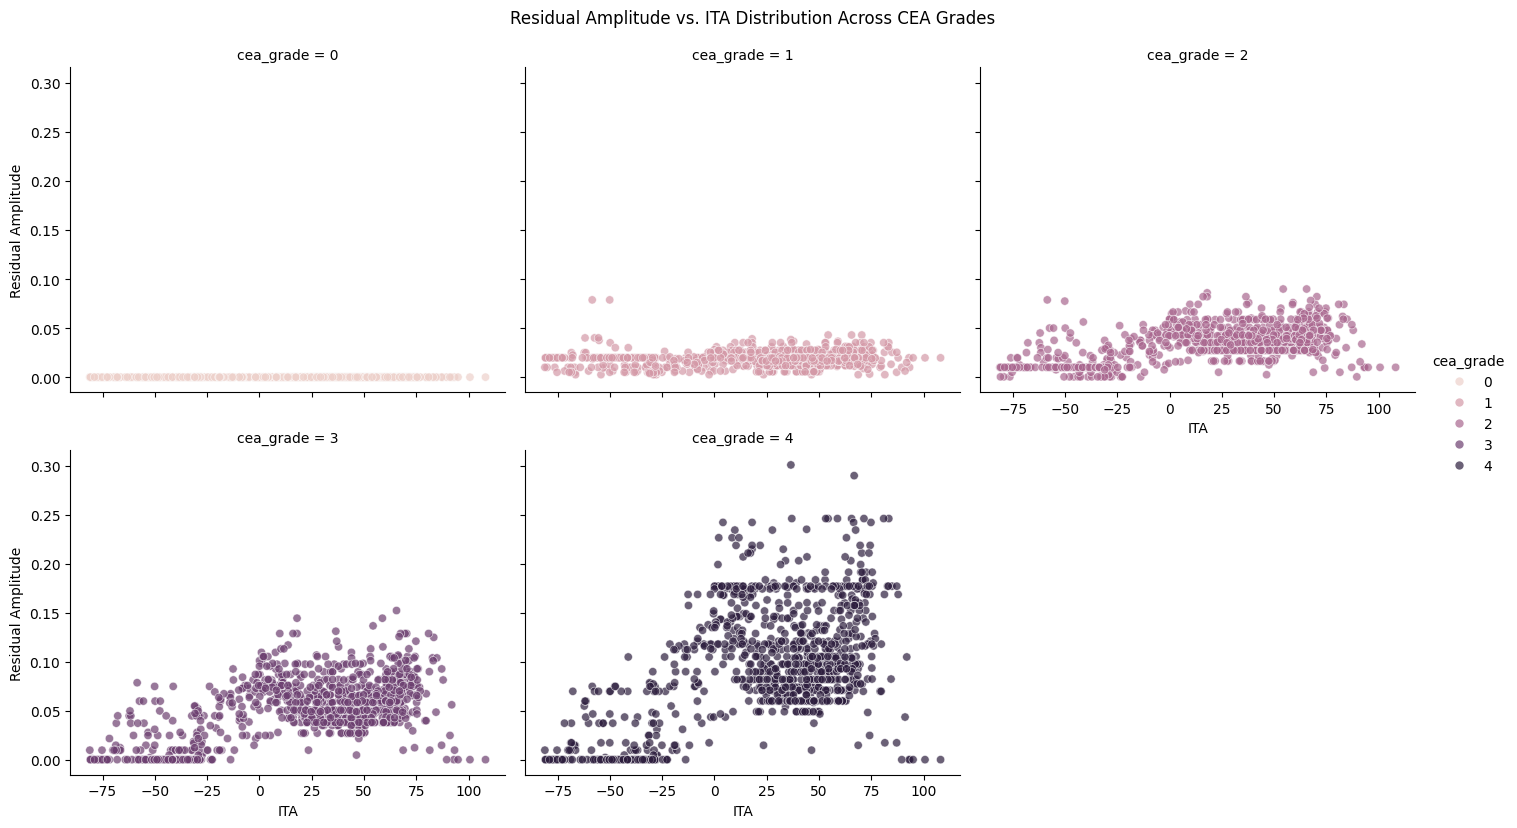

In [29]:
g = sns.relplot(
    data=df,
    x='ita',
    y='residual_amp',
    col='cea_grade',
    hue='cea_grade',
    alpha=0.7,
    kind='scatter',
    col_wrap=3,  # Adjust number of columns per row as needed
    height=4,
    aspect=1.2,
)

g.fig.suptitle(
    'Residual Amplitude vs. ITA Distribution Across CEA Grades', y=1.03
)
g.set_axis_labels('ITA', 'Residual Amplitude')
plt.show()

In [45]:
from scipy.stats import pearsonr
for grade in [1,2,3,4]:
    subset = df[df.cea_grade==grade]
    r, p = pearsonr(subset['ita'], subset['residual_amp'])
    print(f"Grade {grade}: r={r:.3f}, p={p:.4f}")

Grade 1: r=0.107, p=0.0007
Grade 2: r=0.460, p=0.0000
Grade 3: r=0.509, p=0.0000
Grade 4: r=0.506, p=0.0000


## 3B · Chromophore Drift Stats Table

In [30]:
data = df[['mel_drift','out_drift','oxy_out_drift','eu_out_drift','cea_grade']].copy()
data.head()

,mel_drift,out_drift,oxy_out_drift,eu_out_drift,cea_grade
0,0.0000,0.0000,0.0000,0.0000,0
1,-0.0004,-0.0146,-0.0182,0.0070,1
2,0.0016,-0.0143,-0.0182,0.0071,2
3,0.0042,-0.0140,-0.0181,0.0071,3
4,0.0116,-0.0130,-0.0180,0.0073,4


In [36]:

# Define the metrics to aggregate
metrics = ['mel_drift', 'out_drift', 'oxy_out_drift', 'eu_out_drift']

# Compute mean and standard deviation grouped by cea_grade
agg_df = data.groupby('cea_grade')[metrics].agg(['mean', 'std'])

# Combine into a clean 'mean ± std' format
result_df = pd.DataFrame(index=agg_df.index)
for col in metrics:
  mean_val = agg_df[(col, 'mean')]
  std_val = agg_df[(col, 'std')]
  result_df[col] = (
      mean_val.map('{:.3f}'.format) + ' ± ' + std_val.map('{:.3f}'.format)
  )

# Display the formatted table
print(result_df.to_string())

               mel_drift       out_drift   oxy_out_drift   eu_out_drift
cea_grade                                                              
0          0.000 ± 0.000   0.000 ± 0.000   0.000 ± 0.000  0.000 ± 0.000
1          0.001 ± 0.016  -0.004 ± 0.014  -0.018 ± 0.006  0.018 ± 0.018
2          0.002 ± 0.016  -0.003 ± 0.014  -0.018 ± 0.006  0.018 ± 0.018
3          0.003 ± 0.015  -0.003 ± 0.014  -0.018 ± 0.006  0.018 ± 0.018
4          0.003 ± 0.014  -0.003 ± 0.014  -0.018 ± 0.006  0.018 ± 0.018
